# Parameters

In [1]:
# Importation
import sys
import os
from pathlib import Path
import math

repo_root = Path.cwd().parent  # adjust if notebook is in a subfolder, e.g. Path.cwd().parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

import src.DEM_dry_granular_flow
print(src.DEM_dry_granular_flow.__doc__)

# Local paths are defined in `paths.py` (gitignored, not distributed).
# Data are split into these two drivers
from paths import (
    DATA_FOLDER_1, RAW_DATA_FOLDER_1, # First driver
    DATA_FOLDER_2, RAW_DATA_FOLDER_2 # Second driver
)




Scripts and notebooks for extracting and post-processing DEM simulation data (Rocky) to investigate the influence of porous erodible bed parameters on the mobility and entrainment of steady granular flows. Developed as part of Camille Huitorel’s PhD research at SLF Davos and ETH Zurich.


In [6]:
# PARAMETERS
# --------------------------------------------------
## CONSTANTS
# --------------------------------------------------
DIAMETER_P_BED = 0.02
DIAMETER_P_GF = 0.06
RHO_P_BED = 500
VOLUME_P_BED = (4/3)*math.pi*(DIAMETER_P_BED/2)**3
MASS_PARTICLE_BED = RHO_P_BED * VOLUME_P_BED
MASS_PARTICLE_GF = 400 * (4/3)*math.pi*(0.06/2)**3

V_TH = 0.2  # m/s velocity threshold

X_LOCAL_MAGHNITUDES = [0.06, 0.6, 1.6]
POSITIONS = [20, 40, 60, 80]

# --------------------------------------------------
## PARAMETER VALUES
# --------------------------------------------------
SLOPES        = [0, 5, 10, 15, 20, 25, 30, 35]                        # [°]
DEPTHS        = [25, 50, 75, 100, 150]                      # [cm]
BED_STRENGTHS = [960, 3000, 7000, 10000, 20000, 50000]      # [Pa]
POROSITIES    = [40, 50, 60, 70, 80]                        # Rocky naming convention [%]

# --------------------------------------------------
## PARAMETER METADATA
# --------------------------------------------------
param_meta = {
    "slope":       {"xlabel": r"$\theta$",          "scale": 1.0,    "reference": 30},
    "beddepth":    {"xlabel": r"$h_{bed}$ [m]",     "scale": 1/100,  "reference": 0.75},
    "bedstrength": {"xlabel": r"$\tau_{bed}$ [kPa]","scale": 1/1000, "reference": 0.96},
    "bedporosity": {"xlabel": r"$\phi_{bed}$ [-]",  "scale": None,   "reference": 0.17},
}

# --------------------------------------------------
## PARAMETER SETS
# --------------------------------------------------
def get_rocky_filename(key: str, p: int) -> str:
    """Build the Rocky folder name for a given parameter key and value.
    Special case: porosity == 80 uses a different naming convention (960Pa instead of no strength).
    """
    if key == "slope":
        return f"80porosity_2000Pa_100m_75cm_{p}XSlope_hmax3m_uf19m-s"
    elif key == "beddepth":
        return f"80porosity_2000Pa_100m_{p}cm_30XSlope_hmax3m_uf19m-s"
    elif key == "bedstrength":
        return f"80porosity_{p}Pa_100m_75cm_30XSlope_hmax3m_uf19m-s"
    elif key == "bedporosity":
        if p == 80:
            return f"{p}porosity_960Pa_100m_75cm_30XSlope_hmax3m_uf19m-s"  # ← special case
        else:
            return f"{p}porosity_100m_75cm_30XSlope_hmax3m_uf19m-s"
    else:
        raise ValueError(f"Unknown parameter key: {key}")

param_sets = [
    {
        "key":              "slope",
        "param_values":     SLOPES,
        "xticks":  [0, 5, 10, 15, 20, 25, 30, 35],
        "output_subfolder": "effect_slope",
        "data_folder":      DATA_FOLDER_1,
        "raw_data_folder":  RAW_DATA_FOLDER_1,
    },
    {
        "key":              "beddepth",
        "param_values":     DEPTHS,
        "xticks":  [0, 0.25, 0.5, 0.75, 1.0, 1.5],
        "output_subfolder": "effect_bed_depth",
        "data_folder":      DATA_FOLDER_1,
        "raw_data_folder":  RAW_DATA_FOLDER_1,
    },
    {
        "key":              "bedstrength",
        "param_values":     BED_STRENGTHS,
        "xticks":  [0.96, 3, 7, 10, 20, 50],
        "output_subfolder": "effect_bed_strength",
        "data_folder":      DATA_FOLDER_2,
        "raw_data_folder":  RAW_DATA_FOLDER_2,
    },
    {
        "key":              "bedporosity",
        "param_values":     POROSITIES,
        "xticks":  [0.61, 0.48, 0.38, 0.30, 0.17],
        "output_subfolder": "effect_porosity_unchangedbondstrength",
        "data_folder":      DATA_FOLDER_2,
        "raw_data_folder":  RAW_DATA_FOLDER_2,
    },
]

# Pre post-processing

## Total momentum

In [ ]:
# --------------------------------------------------
# IMPORTS
# --------------------------------------------------
import os
import time
import json
from typing import TypedDict
from pathlib import Path
import numpy as np

# --------------------------------------------------
# CONSTANTS
# --------------------------------------------------
momentum_curves_name = "total_momentum.json"

# --------------------------------------------------
# TYPE DEFINITIONS
# --------------------------------------------------
class AbsoluteVelocity(TypedDict):
    timestep_s:    float
    granular_flow: np.ndarray
    bed:           np.ndarray

class Momentum(TypedDict):
    timestep_s: float
    granular_flow : float
    bed : float
    total:      float


# --------------------------------------------------
# CORE FUNCTIONS
# --------------------------------------------------
def load_velocity(rocky_filepath: Path, step: int) -> AbsoluteVelocity:
    with open(rocky_filepath / f"bed_{step}.json", "r") as file:
        dict_timestep_bed = json.load(file)
    with open(rocky_filepath / f"gf_{step}.json", "r") as file:
        dict_timestep_gf  = json.load(file)
    return AbsoluteVelocity(
        timestep_s    = float(dict_timestep_gf["second"]),
        granular_flow = np.array(dict_timestep_gf["absolute_velocity"]),
        bed           = np.array(dict_timestep_bed["absolute_velocity"]),
    )


def compute_total_momentum(absolute_velocity: AbsoluteVelocity) -> Momentum:
    momentum_gf  = np.sum(MASS_PARTICLE_GF * absolute_velocity["granular_flow"])
    bed_velocity = absolute_velocity["bed"]
    momentum_bed = np.sum(MASS_PARTICLE_BED * bed_velocity[np.where(bed_velocity > V_TH)])
    return Momentum(
        granular_flow = momentum_gf,
        bed = momentum_bed,
        total      = momentum_gf + momentum_bed,
        timestep_s = absolute_velocity["timestep_s"],
    )


def load_or_compute_momentum(rocky_filepath: Path, step: int) -> Momentum:
    cache_path = rocky_filepath / f"momentum_{step}.json"
    if cache_path.exists():
        with cache_path.open("r") as json_file:
            return json.load(json_file)
    print(f"    Step {step}: computing momentum ...")
    t0       = time.time()
    velocity = load_velocity(rocky_filepath, step=step)
    momentum = compute_total_momentum(velocity)
    with cache_path.open("w") as json_file:
        json.dump(momentum, json_file)
    print(f"    Done in {time.time() - t0:.2f}s")
    return momentum


def compute_momentum_curves(
    key:              str,
    param_values:     list,
    raw_data_folder:  Path,
    data_folder:      Path,
    output_subfolder: str,
) -> None:
    """
    For each value in param_values:
      - builds the Rocky folder name via get_rocky_filename(key, p)
      - loads or computes momentum at every timestep
      - saves all curves to data_folder / output_subfolder / total_momentum.json
    """
    momentum_curves = {}

    for param in param_values:
        print(f"  → param = {param}")
        rocky_filename  = get_rocky_filename(key, param)
        rocky_file_path = raw_data_folder / rocky_filename

        if not rocky_file_path.exists():
            print(f"    ✗ Folder not found, skipping: {rocky_file_path}")
            continue

        gf_files_list = sorted([
            f for f in os.listdir(rocky_file_path)
            if f.startswith("gf_") and f.endswith(".json")
        ])

        seconds, momentum_bed, momentums = [], [], []
        for step in range(len(gf_files_list)):
            momentum = load_or_compute_momentum(rocky_file_path, step)
            momentum_bed.append(momentum["bed"])
            seconds.append(momentum["timestep_s"])
            momentums.append(momentum["total"])

        momentum_curves[str(param)] = {
            "seconds":        seconds,
            "momentum_bed" : momentum_bed
            "total_momentum": momentums,
        }

    output_folder = data_folder / output_subfolder
    output_folder.mkdir(parents=True, exist_ok=True)
    output_path = output_folder / momentum_curves_name
    with open(output_path, "w") as outfile:
        json.dump(momentum_curves, outfile)
    print(f"  ✓ Saved → {output_path}\n")


# --------------------------------------------------
# RUN ALL PARAMETER SETS
# --------------------------------------------------
for ps in param_sets:
    meta   = param_meta[ps["key"]]
    xticks = ps["xticks"]

    print(f"{'='*55}")
    print(f"  Parameter : {ps['key']}")
    print(f"  Label     : {meta['xlabel']}")
    print(f"  Scale     : {meta['scale']}")
    print(f"  Ticks     : {xticks}")
    print(f"{'='*55}\n")

    compute_momentum_curves(
        key              = ps["key"],
        param_values     = ps["param_values"],
        raw_data_folder  = ps["raw_data_folder"],
        data_folder      = ps["data_folder"],
        output_subfolder = ps["output_subfolder"],
    )

  Parameter : slope
  Label     : $\theta\;[^\circ]$
  Scale     : 1.0
  Ticks     : [0, 5, 10, 15, 20, 25, 30, 35]

  → param = 0
  → param = 5
  → param = 10
  → param = 15
  → param = 20
  → param = 25
  → param = 30
  → param = 35
  ✓ Saved → d:\huitorel\Documents\Github\Collaspe\experiments\inlet\erodible_bed\dry\dense_flow\2cmparticlesbed\homogeneous\PostProcess\data\effect_slope\total_momentum.json

  Parameter : beddepth
  Label     : $h_{\mathrm{bed}}\;[\mathrm{m}]$
  Scale     : 0.01
  Ticks     : [0, 0.25, 0.5, 0.75, 1.0, 1.5]

  → param = 25
  → param = 50
    Step 45: computing momentum ...
    Done in 2.24s
    Step 46: computing momentum ...
    Done in 3.07s
    Step 47: computing momentum ...
    Done in 3.27s
    Step 48: computing momentum ...
    Done in 2.92s
    Step 49: computing momentum ...
    Done in 3.20s
    Step 50: computing momentum ...
    Done in 3.33s
    Step 51: computing momentum ...
    Done in 2.91s
    Step 52: computing momentum ...
    Done in

## Energies (kinetic, potential)

In [ ]:
# --------------------------------------------------
# DELETE ENERGY CACHE FILES
# Two types of files are deleted:
#   1. energies_{step}.json  — per-step cache in each Rocky simulation folder
#   2. energies.json         — aggregated output in each data subfolder
# --------------------------------------------------
import os
from pathlib import Path

energies_curves_name = "energies.json"
dry_run = True  # ← set to False to actually delete

total_cache, total_output = 0, 0

for ps in param_sets:
    print(f"{'=' * 55}")
    print(f"  Parameter : {ps['key']}")
    print(f"{'=' * 55}")

    # ---------- 1. per-step cache files ----------
    for param in ps["param_values"]:
        rocky_filename = get_rocky_filename(ps["key"], param)
        rocky_file_path = ps["raw_data_folder"] / rocky_filename

        if not rocky_file_path.exists():
            print(f"  ✗ Folder not found, skipping: {rocky_file_path}")
            continue

        cache_files = sorted(rocky_file_path.glob("energies_*.json"))
        print(f"  → param={param} | {len(cache_files)} cache file(s) found")

        for f in cache_files:
            if dry_run:
                print(f"    [DRY RUN] would delete: {f.name}")
            else:
                f.unlink()
                print(f"    ✓ deleted: {f.name}")
            total_cache += 1

    # ---------- 2. aggregated output file ----------
    output_path = ps["data_folder"] / ps["output_subfolder"] / energies_curves_name

    if output_path.exists():
        if dry_run:
            print(f"  [DRY RUN] would delete output: {output_path}")
        else:
            output_path.unlink()
            print(f"  ✓ deleted output: {output_path}")
        total_output += 1
    else:
        print(f"  (no output file at {output_path})")

print(f"\n{'=' * 55}")
action = "Would delete" if dry_run else "Deleted"
print(f"  {action} {total_cache} cache file(s) and {total_output} output file(s).")
if dry_run:
    print("  → Set dry_run = False to actually delete.")
print(f"{'=' * 55}")


  Parameter : slope
  → param=0 | 8 cache file(s) found
    ✓ deleted: energies_0.json
    ✓ deleted: energies_1.json
    ✓ deleted: energies_2.json
    ✓ deleted: energies_3.json
    ✓ deleted: energies_4.json
    ✓ deleted: energies_5.json
    ✓ deleted: energies_6.json
    ✓ deleted: energies_7.json
  → param=5 | 0 cache file(s) found
  → param=10 | 0 cache file(s) found
  → param=15 | 0 cache file(s) found
  → param=20 | 0 cache file(s) found
  → param=25 | 0 cache file(s) found
  → param=30 | 0 cache file(s) found
  → param=35 | 0 cache file(s) found
  (no output file at d:\huitorel\Documents\Github\Collaspe\experiments\inlet\erodible_bed\dry\dense_flow\2cmparticlesbed\homogeneous\PostProcess\data\effect_slope\energies.json)
  Parameter : beddepth
  → param=25 | 0 cache file(s) found
  → param=50 | 0 cache file(s) found
  → param=75 | 0 cache file(s) found
  → param=100 | 0 cache file(s) found
  → param=150 | 0 cache file(s) found
  (no output file at d:\huitorel\Documents\Github\

In [14]:
# --------------------------------------------------
# IMPORTS
# --------------------------------------------------
import os
import time
import json
import math
from typing import Tuple, TypedDict
from pathlib import Path
import numpy as np


# --------------------------------------------------
# CONSTANTS
# --------------------------------------------------
energies_curves_name = "energies.json"


# --------------------------------------------------
# TYPE DEFINITIONS
# --------------------------------------------------
class AbsoluteVelocity(TypedDict):
    timestep_s:    float
    granular_flow: np.ndarray
    bed:           np.ndarray


class ProjectedYCoordinates(TypedDict):
    timestep_s:    float
    granular_flow: np.ndarray
    bed:           np.ndarray


class KineticEnergy(TypedDict):
    timestep_s:    float
    bed:           float
    granular_flow: float
    total:         float


class PotentialEnergy(TypedDict):
    timestep_s:    float
    bed:           float
    granular_flow: float
    total:         float


class Energies(TypedDict):
    timestep_s: float
    kinetic:    KineticEnergy
    potential:  PotentialEnergy


# --------------------------------------------------
# CORE FUNCTIONS
# --------------------------------------------------
def load_velocity_and_coordinates(
    rocky_filepath: Path, step: int, slope: int, hbed:float
) -> Tuple[AbsoluteVelocity, ProjectedYCoordinates]:
    with open(rocky_filepath / f"bed_{step}.json", "r") as f:
        dict_bed = json.load(f)
    with open(rocky_filepath / f"gf_{step}.json", "r") as f:
        dict_gf  = json.load(f)

    timestep_s = float(dict_gf["second"])

    absolute_velocity = AbsoluteVelocity(
        timestep_s    = timestep_s,
        granular_flow = np.array(dict_gf["absolute_velocity"]),
        bed           = np.array(dict_bed["absolute_velocity"]),
    )

    sin_t = np.sin(np.radians(slope))
    cos_t = np.cos(np.radians(slope))

    # term to prevent nagtive values if particles below the projected reference, if existing slope. Projected y : y', should be equal to zero at x=120m (100 m along bed)
    corr_y_ref = -sin_t * 120  + cos_t * 0

    projected_y = ProjectedYCoordinates(
        timestep_s    = timestep_s,
        granular_flow = -sin_t * np.array(dict_gf["x"])  + cos_t * (np.array(dict_gf["y"])  - (4.25 - (hbed - 0.75))) -corr_y_ref,
        bed           = -sin_t * np.array(dict_bed["x"]) + cos_t * (np.array(dict_bed["y"]) - (4.25 - (hbed - 0.75))) -corr_y_ref,
    )

    return absolute_velocity, projected_y


def compute_kinetic_energy(absolute_velocity: AbsoluteVelocity) -> KineticEnergy:
    ke_bed = float(np.sum(0.5 * MASS_PARTICLE_BED * absolute_velocity["bed"] ** 2))
    ke_gf  = float(np.sum(0.5 * MASS_PARTICLE_GF  * absolute_velocity["granular_flow"] ** 2))
    return KineticEnergy(
        timestep_s    = absolute_velocity["timestep_s"],
        bed           = ke_bed,
        granular_flow = ke_gf,
        total         = ke_bed + ke_gf,
    )


def compute_potential_energy(y: ProjectedYCoordinates) -> PotentialEnergy:
    ep_bed = float(MASS_PARTICLE_BED * 9.81 * np.sum(y["bed"]))
    ep_gf  = float(MASS_PARTICLE_GF  * 9.81 * np.sum(y["granular_flow"]))
    return PotentialEnergy(
        timestep_s    = y["timestep_s"],
        bed           = ep_bed,
        granular_flow = ep_gf,
        total         = ep_bed + ep_gf,
    )


def build_energies(ke: KineticEnergy, ep: PotentialEnergy) -> Energies:
    return Energies(
        timestep_s = ke["timestep_s"],
        kinetic    = ke,
        potential  = ep,
    )


def load_or_compute_energies(rocky_filepath: Path, step: int, slope: int, hbed: float) -> Energies:
    cache_path = rocky_filepath / f"energies_{step}.json"

    if cache_path.exists():
        with cache_path.open("r") as f:
            return json.load(f)

    print(f"    Step {step}: computing energies …")
    t0 = time.time()

    velocity, ycoord = load_velocity_and_coordinates(rocky_filepath, step, slope, hbed)
    ke       = compute_kinetic_energy(velocity)
    ep       = compute_potential_energy(ycoord)
    energies = build_energies(ke, ep)

    with cache_path.open("w") as f:
        json.dump(energies, f)

    print(f"    Done in {time.time() - t0:.2f}s")
    return energies


# --------------------------------------------------
# MAIN FUNCTION
# --------------------------------------------------
def compute_energies_curves(
    key:              str,
    param_values:     list,
    raw_data_folder:  Path,
    data_folder:      Path,
    output_subfolder: str,
) -> None:
    """
    For each value in param_values:
      - builds the Rocky folder name via get_rocky_filename(key, p)
      - loads or computes kinetic/potential energies at every timestep
      - saves all curves to data_folder / output_subfolder / energies.json

    Note: slope is needed for the coordinate projection. For non-slope
    parameter sets, the reference slope from param_meta is used.
    """
    energies_curves = {}

    for param in param_values:
        print(f"  → param = {param}")
        rocky_filename  = get_rocky_filename(key, param)
        rocky_file_path = raw_data_folder / rocky_filename

        if not rocky_file_path.exists():
            print(f"    ✗ Folder not found, skipping: {rocky_file_path}")
            continue

        # slope angle for coordinate projection
        slope = param if key == "slope" else param_meta["slope"]["reference"]
        # h bed for correction of the y coordinates, needed in potential energies
        h_bed = (param / 100) if key == "beddepth" else param_meta["beddepth"]["reference"]

        gf_files_list = sorted(
            f for f in os.listdir(rocky_file_path)
            if f.startswith("gf_") and f.endswith(".json")
        )

        seconds                       = []
        ke_bed, ke_gf, ep_bed, ep_gf  = [], [], [], []

        for step in range(len(gf_files_list)):
            energies = load_or_compute_energies(rocky_file_path, step, slope, h_bed)

            seconds.append(energies["timestep_s"])
            ke_bed.append(energies["kinetic"]["bed"])
            ke_gf.append(energies["kinetic"]["granular_flow"])
            ep_bed.append(energies["potential"]["bed"])
            ep_gf.append(energies["potential"]["granular_flow"])

        energies_curves[str(param)] = {
            "seconds": seconds,
            "ke_bed":  ke_bed,
            "ke_gf":   ke_gf,
            "ep_bed":  ep_bed,
            "ep_gf":   ep_gf,
        }

    output_folder = data_folder / output_subfolder
    output_folder.mkdir(parents=True, exist_ok=True)
    output_path = output_folder / energies_curves_name
    with open(output_path, "w") as f:
        json.dump(energies_curves, f)
    print(f"  ✓ Saved → {output_path}\n")


# --------------------------------------------------
# RUN ALL PARAMETER SETS
# --------------------------------------------------
for ps in param_sets:
    meta   = param_meta[ps["key"]]
    xticks = ps["xticks"]

    print(f"{'='*55}")
    print(f"  Parameter : {ps['key']}")
    print(f"  Label     : {meta['xlabel']}")
    print(f"  Scale     : {meta['scale']}")
    print(f"  Ticks     : {xticks}")
    print(f"{'='*55}\n")

    compute_energies_curves(
        key              = ps["key"],
        param_values     = ps["param_values"],
        raw_data_folder  = ps["raw_data_folder"],
        data_folder      = ps["data_folder"],
        output_subfolder = ps["output_subfolder"],
    )

  Parameter : slope
  Label     : $\theta$
  Scale     : 1.0
  Ticks     : [0, 5, 10, 15, 20, 25, 30, 35]

  → param = 0
    Step 0: computing energies …
    Done in 2.85s
    Step 1: computing energies …
    Done in 3.18s
    Step 2: computing energies …
    Done in 3.13s
    Step 3: computing energies …
    Done in 3.14s
    Step 4: computing energies …
    Done in 3.17s
    Step 5: computing energies …
    Done in 3.15s
    Step 6: computing energies …
    Done in 3.15s
    Step 7: computing energies …
    Done in 3.15s
    Step 8: computing energies …
    Done in 3.25s
    Step 9: computing energies …
    Done in 4.36s
    Step 10: computing energies …
    Done in 4.37s
    Step 11: computing energies …
    Done in 4.40s
    Step 12: computing energies …
    Done in 4.34s
    Step 13: computing energies …
    Done in 4.41s
    Step 14: computing energies …
    Done in 4.40s
    Step 15: computing energies …
    Done in 4.38s
    Step 16: computing energies …
    Done in 4.36s
    S

In [ ]:
import json
import os
import numpy as np
import matplotlib.pyplot as plt
# --------------------------------------------------
# FILE NAMES
# --------------------------------------------------
impact_time_filename   = "times_impact_wall.json"
energies_curves_name = "energies.json"

# --------------------------------------------------
# STUDIES + XTICKS — built directly from param_sets
# --------------------------------------------------

studies = [
    (ps["key"], ps["data_folder"] / ps["output_subfolder"], ps["param_values"])
    for ps in param_sets
]

param_xticks = {ps["key"]: ps["xticks"] for ps in param_sets}

# --------------------------------------------------
# FIGURE
# --------------------------------------------------
fig, ax = plt.subplots(
    nrows=1, ncols=len(studies),
    figsize=(2 * len(studies), 4.0),
    sharex="col",
)

# --------------------------------------------------
# MAIN LOOP
# --------------------------------------------------

for row, (key, folder, params) in enumerate(studies):
    print("key:",key)
    meta = param_meta[key]
    with open(folder / energies_curves_name)          as f: energies_data    = json.load(f)
    with open(folder / impact_time_filename)   as f: impact_data   = json.load(f)

    


    colors = plt.cm.Spectral(np.linspace(0, 1, len(param_xticks[key])))
    for i, p in enumerate(params):

        surface = 25 * 1
        t_imp, sum_force = [], []

        for timestep in impact_data["timesteps"]:
            d = impact_data["timesteps"][timestep]
            t_imp.append(float(d["second"]))
            sum_force.append(np.sum(d["Nodal Horizontal Force"]["0"]))

        pressure = [(1 / surface) * f for f in sum_force]
        derivative = np.gradient(pressure, 0.05)
        time_impact = t_imp[np.argmax(derivative)]

        sec = energies_data["seconds"]
        ke = [energies_data[p]['ke_bed'][j] + energies_data[p]['ke_gf'][j] for j in range(len(energies_data[p]['ke_gf']))]
        ep = [energies_data[p]['ep_bed'][j] + energies_data[p]['ke_gf'][j] for j in range(len(energies_data[p]['ep_gf']))]
        total_energy = [ke[j]+ep[j] for j in range(len(ke))]

        ax[row,0].plot(sec, total_energy, color=colors[i])
        ax.axvline(x=time_impact, color="gray", linestyle="--", linewidth=1.2, label=r"$t_{\mathrm{impact}}=$"+f"{time_impact}s")

    

key: slope
  param: 0
    ✗ impact file not found, skipping: d:\huitorel\Documents\Github\Collaspe\experiments\inlet\erodible_bed\dry\dense_flow\2cmparticlesbed\homogeneous\PostProcess\raw_data\80porosity_2000Pa_100m_75cm_0XSlope_hmax3m_uf19m-s\times_impact_wall.json
  param: 5
    ✗ impact file not found, skipping: d:\huitorel\Documents\Github\Collaspe\experiments\inlet\erodible_bed\dry\dense_flow\2cmparticlesbed\homogeneous\PostProcess\raw_data\80porosity_2000Pa_100m_75cm_5XSlope_hmax3m_uf19m-s\times_impact_wall.json
  param: 10
    ✗ impact file not found, skipping: d:\huitorel\Documents\Github\Collaspe\experiments\inlet\erodible_bed\dry\dense_flow\2cmparticlesbed\homogeneous\PostProcess\raw_data\80porosity_2000Pa_100m_75cm_10XSlope_hmax3m_uf19m-s\times_impact_wall.json
  param: 15
    ✗ impact file not found, skipping: d:\huitorel\Documents\Github\Collaspe\experiments\inlet\erodible_bed\dry\dense_flow\2cmparticlesbed\homogeneous\PostProcess\raw_data\80porosity_2000Pa_100m_75cm_15XS

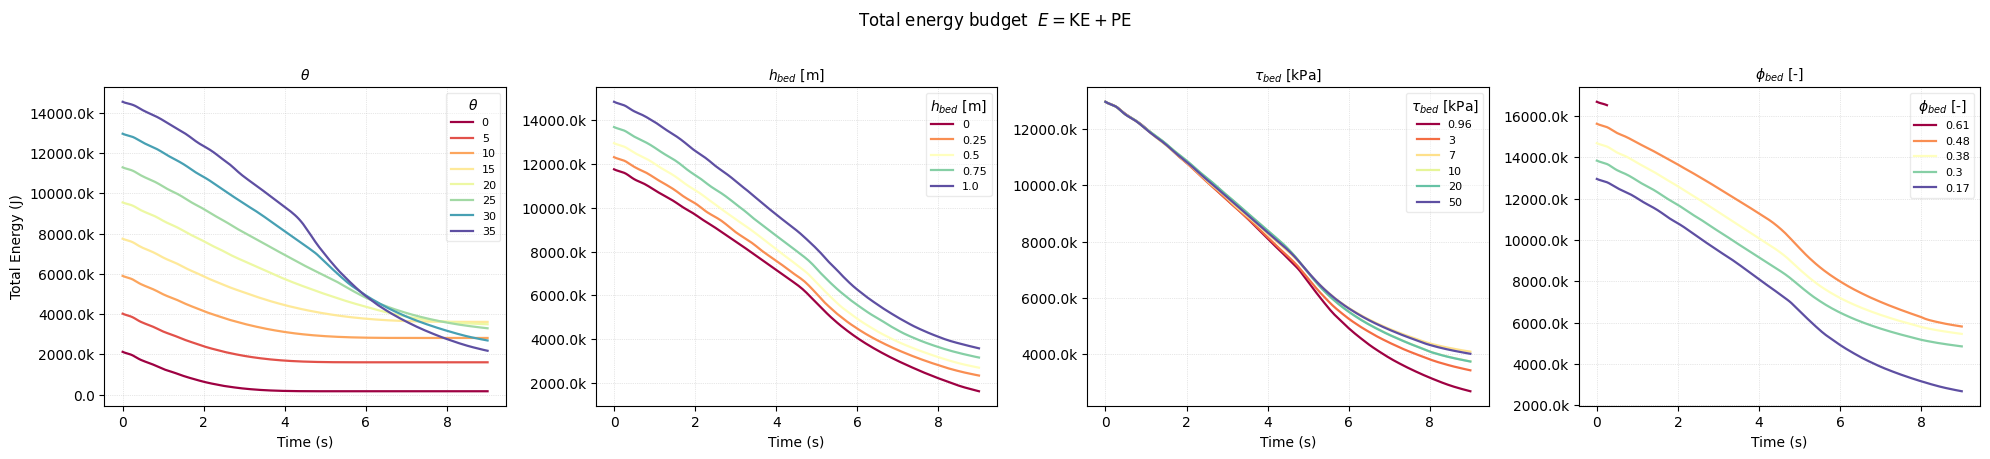

Saved: F:\Github\Collapse_2025R1\experiments\erodible_bed\dry\dense_flow\homogeneous\PostProcess\data\effect_porosity_unchangedbondstrength\energies.json


In [18]:
import json
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# --------------------------------------------------
# FILE NAMES
# --------------------------------------------------
impact_time_filename = "times_impact_wall.json"
energies_curves_name = "energies.json"

# --------------------------------------------------
# STUDIES + XTICKS — built directly from param_sets
# --------------------------------------------------
studies = [
    (ps["key"], ps["data_folder"] / ps["output_subfolder"], ps["param_values"], ps["raw_data_folder"])
    for ps in param_sets
]

param_xticks = {ps["key"]: ps["xticks"] for ps in param_sets}

# --------------------------------------------------
# FIGURE
# --------------------------------------------------
fig, axes = plt.subplots(
    nrows=1, ncols=len(studies),
    figsize=(5 * len(studies), 4.5),
    sharey=False,
)

# --------------------------------------------------
# MAIN LOOP
# --------------------------------------------------
for col, (key, folder, params, raw_data_folder) in enumerate(studies):
    print(f"key: {key}")
    meta = param_meta[key]
    ax   = axes[col]

    with open(folder / energies_curves_name) as f:
        energies_data = json.load(f)

    colors = plt.cm.Spectral(np.linspace(0, 1, len(params)))

    for i, p in enumerate(params):
        print(f"  param: {p}")

        # ── impact time (one file per simulation) ──────────────────────────
        rocky_filename = get_rocky_filename(key, p)
        impact_path    = raw_data_folder / rocky_filename / impact_time_filename

        if not impact_path.exists():
            print(f"    ✗ impact file not found, skipping: {impact_path}")
            time_impact = None
        else:
            with open(impact_path) as f:
                impact_data = json.load(f)

            surface    = 25 * 1
            t_imp, sum_force = [], []

            for timestep in impact_data["timesteps"]:
                d = impact_data["timesteps"][timestep]
                t_imp.append(float(d["second"]))
                sum_force.append(np.sum(d["Nodal Horizontal Force"]["0"]))

            pressure    = [(1 / surface) * f for f in sum_force]
            derivative  = np.gradient(pressure, 0.05)
            time_impact = t_imp[np.argmax(derivative)]

        # ── energy curves ──────────────────────────────────────────────────
        sp  = str(p)
        if sp not in energies_data:
            print(f"    ✗ no energy data for param {p}, skipping")
            continue

        sec = energies_data[sp]["seconds"]
        ke  = [energies_data[sp]["ke_bed"][j] + energies_data[sp]["ke_gf"][j]
               for j in range(len(sec))]
        ep  = [energies_data[sp]["ep_bed"][j] + energies_data[sp]["ep_gf"][j]
               for j in range(len(sec))]
        total_energy = [ke[j] + ep[j] for j in range(len(sec))]

        label = f"{param_xticks[key][i]}"
        ax.plot(sec, total_energy, color=colors[i], linewidth=1.6, label=label)

        if time_impact is not None:
            ax.axvline(x=time_impact, color=colors[i], linestyle="--",
                       linewidth=1.0, alpha=0.6)

    # ── axes formatting ────────────────────────────────────────────────────
    ax.set_xlabel("Time (s)", fontsize=10)
    if col == 0:
        ax.set_ylabel("Total Energy (J)", fontsize=10)
    ax.set_title(meta["xlabel"], fontsize=10)
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(
        lambda x, _: f"{x/1e3:.1f}k" if abs(x) >= 1e3 else f"{x:.1f}"
    ))
    ax.legend(fontsize=8, framealpha=0.4, title=meta["xlabel"])
    ax.grid(True, linestyle=":", linewidth=0.5, alpha=0.6)

fig.suptitle(
    r"Total energy budget  $E = \mathrm{KE} + \mathrm{PE}$",
    fontsize=12, y=1.01
)
fig.tight_layout()

# output_path = Path("energy_summary.png")
# fig.savefig(output_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {output_path}")

# Figures - paper

## Figure A - Temporal Evolution

## Figure B - Spatio-temporal Evolution velocity and flowing mass

## Figure C - Local erosion and deposition

## Figure D - Spatio-temporal solid fraction and velocity

## Discussion summary figure

key: slope
value : 0
value : 5
value : 10
value : 15
value : 20
value : 25
value : 30
value : 35
0
pos:20m
5
pos:20m
10
pos:20m
15
pos:20m
20
pos:20m
25
pos:20m
30
pos:20m
35
pos:20m
0
pos:40m
5
pos:40m
10
pos:40m
15
pos:40m
20
pos:40m
25
pos:40m
30
pos:40m
35
pos:40m
10
pos:60m
15
pos:60m
20
pos:60m
25
pos:60m
30
pos:60m
35
pos:60m
10
pos:80m
15
pos:80m
20
pos:80m
25
pos:80m
30
pos:80m
35
pos:80m
key: beddepth
value : 25
value : 50
value : 75
value : 100
value : 150
25
pos:20m
50
pos:20m
75
pos:20m
100
pos:20m
150
pos:20m
25
pos:40m
50
pos:40m
75
pos:40m
100
pos:40m
150
pos:40m
25
pos:60m
50
pos:60m
75
pos:60m
100
pos:60m
150
pos:60m
25
pos:80m
50
pos:80m
75
pos:80m
100
pos:80m
150
pos:80m
key: bedstrength
value : 960
value : 3000
value : 7000
value : 10000
value : 20000
value : 50000
960
pos:20m
3000
pos:20m
7000
pos:20m
10000
pos:20m
20000
pos:20m
50000
pos:20m
960
pos:40m
3000
pos:40m
7000
pos:40m
10000
pos:40m
20000
pos:40m
50000
pos:40m
960
pos:60m
3000
pos:60m
7000
pos:60m
10000

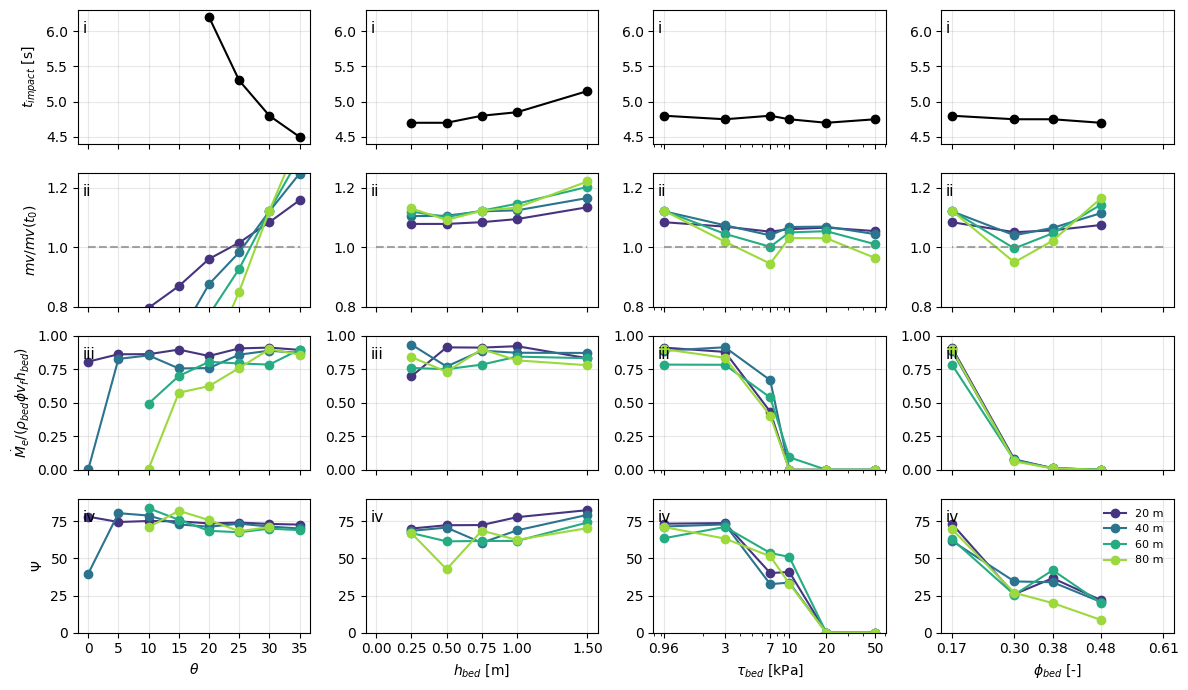

In [19]:
import json
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.ticker import FixedLocator, FuncFormatter
from scipy.signal import savgol_filter

# --------------------------------------------------
# FIGURE CONSTANTS (local to this figure only)
# --------------------------------------------------
h_bed_ref      = 0.75
phi_ref       = 0.17

colors        = plt.cm.viridis(np.linspace(0.15, 0.85, len(POSITIONS)))
window_points = 9
polyorder     = 2

# --------------------------------------------------
# FILE NAMES
# --------------------------------------------------
impact_time_filename   = "times_impact_wall.json"
fronts_curves          = "frontevolution_frontvelocityprofile.json"
momentum_curves_name   = "total_momentum.json"
mass_rates_curves_name = "mass_rate_tripleconditions.json"
erosion_rates_filename = "local_erosion_rate.json"

# --------------------------------------------------
# FORMATTER
# --------------------------------------------------
def log_tick_formatter(x, pos):
    return f"{int(x)}" if np.isclose(x, round(x)) else f"{x:.2g}"

# --------------------------------------------------
# STUDIES + XTICKS — built directly from param_sets
# --------------------------------------------------

studies = [
    (ps["key"], ps["data_folder"] / ps["output_subfolder"], ps["param_values"])
    for ps in param_sets
]

param_xticks = {ps["key"]: ps["xticks"] for ps in param_sets}

# --------------------------------------------------
# INITIAL MOMENTUM  (identical for all simulations)
# --------------------------------------------------
ref_folder = DATA_FOLDER_1 / "effect_bed_depth"
with open(ref_folder / momentum_curves_name) as f:
    P0 = json.load(f)["25"]["total_momentum"][0]

# --------------------------------------------------
# FIGURE
# --------------------------------------------------
fig, ax = plt.subplots(
    nrows=4, ncols=len(studies),
    figsize=(3 * len(studies), 7.0),
    sharex="col",
)

# --------------------------------------------------
# MAIN LOOP
# --------------------------------------------------
for col, (key, folder, params) in enumerate(studies):
    print("key:",key)
    meta = param_meta[key]

    with open(folder / fronts_curves)          as f: front_data    = json.load(f)
    with open(folder / momentum_curves_name)   as f: momentum_data = json.load(f)
    with open(folder / mass_rates_curves_name) as f: mass_data     = json.load(f)
    with open(folder / erosion_rates_filename) as f: erosion_data  = json.load(f)
    with open(folder / impact_time_filename)   as f: impact_data   = json.load(f)

    # ---------- ROW 1: IMPACT TIME ----------
    xvals, tvals = [], []
    for i, p in enumerate(params):
        print(f"value : {p}")
        t = impact_data[str(p)]
        tvals.append(t if t > 0 else np.nan)
        xvals.append(param_xticks[key][i] if key == "bedporosity" else p * meta["scale"])

    ax[0, col].plot(xvals, tvals, "o-", color="black")
    ax[0, col].set_ylim(4.4, 6.3)

    # ---------- ROWS 2–4 ----------
    for color, pos in zip(colors, POSITIONS):

        Pvals, Mevals, Psivals = [], [], []

        for i, p in enumerate(params):

            # --- front arrival ---
            x_f = np.array(front_data[str(p)]["x_f"])
            v_f = np.array(front_data[str(p)]["v_f"])
            valid = np.isfinite(x_f)
            idx = np.where(valid & (x_f >= pos))[0]
            if len(idx) == 0:
                Pvals.append(np.nan)
                Mevals.append(np.nan)
                Psivals.append(np.nan)
                continue
            it = idx[0]

            # ---------- momentum ----------
            Pvals.append(momentum_data[str(p)]["total_momentum"][it] / P0)

            # ---------- entrainment ----------
            v_front = v_f[it]
            h = p/100 if key=="beddepth" else h_bed_ref
            phi = param_xticks[key][i] if key=="bedporosity" else phi_ref
            Me = mass_data[str(V_TH)][str(p)]["mass_rates"][it]
            Mevals.append(Me / (phi * RHO_P_BED * v_front * h))

            # ---------- ψ (UPDATED, SMOOTHED) ----------
            df_front = pd.DataFrame({"x_f": x_f, "v_f": v_f}).dropna().sort_values("x_f")
            if len(df_front) >= window_points:
                w = window_points if window_points % 2 else window_points - 1
                vf_smooth = savgol_filter(df_front["v_f"], w, polyorder)
            else:
                vf_smooth = df_front["v_f"].values
            print(p)
            print(f"pos:{pos}m")
            vf_pos = np.interp(pos, df_front["x_f"], vf_smooth)
            psi = erosion_data[str(pos)][str(p)] / vf_pos

            Psivals.append(-1*(np.degrees(np.arctan(psi))))

        x_vals_row = [
            param_xticks[key][i] if key == "bedporosity" else p * meta["scale"]
            for i, p in enumerate(params)
        ]
        ax[1, col].plot(x_vals_row, Pvals,   "o-", color=color)
        ax[2, col].plot(x_vals_row, Mevals,  "o-", color=color)
        ax[3, col].plot(x_vals_row, Psivals, "o-", color=color, label=f"{pos} m")

    ax[1, col].set_ylim(0.8, 1.25)
    ax[1, col].hlines(1, param_xticks[key][0], param_xticks[key][-1], "gray", "--", alpha=0.7)
    ax[2, col].set_ylim(0, 1)
    ax[3, col].set_ylim(0, 90)

    for r in range(4):
        ax[r, col].grid(True, alpha=0.3)

    if key == "bedstrength":
        for r in range(4):
            ax[r, col].set_xscale("log")
            ax[r, col].xaxis.set_major_locator(FixedLocator(param_xticks[key]))
            ax[r, col].xaxis.set_major_formatter(FuncFormatter(log_tick_formatter))
    else:
        for r in range(4):
            ax[r, col].set_xticks(param_xticks[key])

    ax[3, col].set_xlabel(meta["xlabel"])

# --------------------------------------------------
# LABELS & LEGEND
# --------------------------------------------------
panel_labels = ["i", "ii", "iii", "iv"]
for step, label in enumerate(panel_labels):
    for irow in range(4):
        ax[step, irow].text(
            0.02, 0.92, label,
            transform=ax[step, irow].transAxes,
            fontsize=11, fontweight="normal",
            va="top", ha="left",
        )

ax[0, 0].set_ylabel(r"$t_{impact}$ [s]")
ax[1, 0].set_ylabel(r"$mv/mv(t_0)$")
ax[2, 0].set_ylabel(r"$\dot{M}_e / (\rho_{bed} \phi v_f h_{bed})$")
ax[3, 0].set_ylabel(r"$\Psi$")

ax[3, 3].legend(frameon=False, fontsize=8)

plt.tight_layout()

fig_name = "summary.svg"
plt.savefig(os.path.join(DATA_FOLDER_1, fig_name), dpi=300)
plt.show()